In [ ]:
from google.colab import files
files.upload()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("spam.csv",encoding='latin-1')

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df = df[['v1','v2']]

In [ ]:
df.columns = ['label','message']

In [ ]:
df.isnull().sum()

,0
label,0
message,0


In [ ]:
df['label'] = df['label'].map({
    'ham' : 0,
    'spam' : 1
})

In [ ]:
x = df['message']

In [ ]:
y = df['label']

In [ ]:
v = CountVectorizer()

In [ ]:
x = v.fit_transform(x)

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [ ]:
model = MultinomialNB()

In [ ]:
model.fit(X_train,Y_train)

MultinomialNB()

In [ ]:
prediction = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(Y_test,prediction)
accuracy

0.97847533632287

In [ ]:
classification_report(Y_test,prediction)

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99       965\n           1       0.91      0.93      0.92       150\n\n    accuracy                           0.98      1115\n   macro avg       0.95      0.96      0.95      1115\nweighted avg       0.98      0.98      0.98      1115\n'

In [ ]:
cm = confusion_matrix(Y_test,prediction)

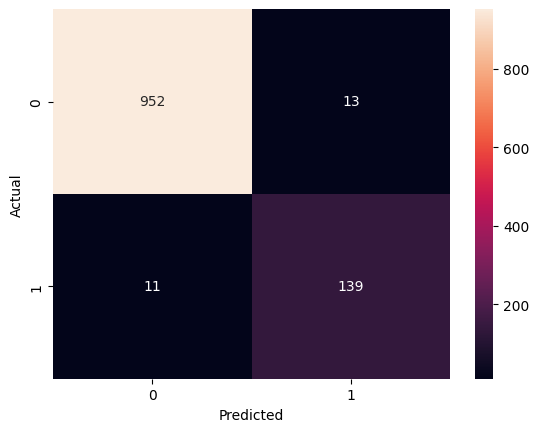

In [ ]:
sns.heatmap(cm,
           annot = True,
           fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
message = ['Congratulations! You won a free iPhone']

In [ ]:
message_vector = v.transform(message)

In [ ]:
result = model.predict(message_vector)


In [ ]:
if result[0]==1:
    print("Spam Message")
else:
    print("Ham Message")


Spam Message
